ML Pipeline

In [11]:
# ==============================
# STEP 1: IMPORT LIBRARIES
# ==============================

# Core
import pandas as pd
import numpy as np
import glob
import time
import json
import joblib
import warnings

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML Pipeline
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    roc_auc_score
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier

# Explainability
import shap

# ------------------------------
# SETTINGS (IMPORTANT)
# ------------------------------
RANDOM_STATE = 42
warnings.filterwarnings("ignore")

# Plot styling (paper quality)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [12]:
# ==============================
# STEP 2: DATA LOADING & PREPROCESSING (IMPROVED)
# ==============================

def load_and_preprocess_data(dataset_path, total_samples=300000):
    
    print("\n--- Loading Data ---")
    
    files = glob.glob(dataset_path, recursive=True)
    
    if not files:
        raise ValueError("No CSV files found. Check dataset path.")
    
    # ------------------------------
    # LOAD DATA (memory-aware)
    # ------------------------------
    df_list = []
    
    for file in files:
        try:
            temp_df = pd.read_csv(file)
            df_list.append(temp_df)
        except Exception as e:
            print(f"Skipping {file}: {e}")
    
    raw_data = pd.concat(df_list, ignore_index=True)
    
    print(f"Total rows loaded: {len(raw_data)}")
    
    # ------------------------------
    # VALIDATE LABEL COLUMN
    # ------------------------------
    if 'label' not in raw_data.columns:
        raise ValueError("Column 'label' not found in dataset.")
    
    # Normalize label values (safety)
    raw_data['label'] = raw_data['label'].astype(str).str.strip()
    
    # ------------------------------
    # SPLIT BENIGN / ATTACK
    # ------------------------------
    benign_df = raw_data[raw_data['label'].str.contains("Benign", case=False)]
    attack_df = raw_data[~raw_data['label'].str.contains("Benign", case=False)]
    
    print(f"Raw Benign: {len(benign_df)}")
    print(f"Raw Attack: {len(attack_df)}")
    
    # ------------------------------
    # BALANCED SAMPLING (40/60)
    # ------------------------------
    target_benign = int(total_samples * 0.40)
    target_attack = int(total_samples * 0.60)
    
    sampled_benign = benign_df.sample(
        n=min(len(benign_df), target_benign),
        random_state=RANDOM_STATE
    )
    
    sampled_attack = attack_df.sample(
        n=min(len(attack_df), target_attack),
        random_state=RANDOM_STATE
    )
    
    data = pd.concat([sampled_benign, sampled_attack])
    data = data.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
    
    # ------------------------------
    # CLEANING
    # ------------------------------
    data.replace([np.inf, -np.inf], np.nan, inplace=True)
    data.dropna(inplace=True)
    
    # ------------------------------
    # TARGET CREATION
    # ------------------------------
    data['binary_target'] = data['label'].apply(
        lambda x: 0 if "Benign" in x else 1
    )
    
    # ------------------------------
    # FEATURE SELECTION
    # ------------------------------
    X = data.drop(columns=['label', 'binary_target'])
    y = data['binary_target']
    
    # Keep only numeric columns (VERY IMPORTANT)
    X = X.select_dtypes(include=[np.number])
    
    feature_names = X.columns.tolist()
    
    print(f"Final dataset shape: {X.shape}")
    
    return X, y, feature_names

In [13]:
# ==============================
# STEP 3: MODEL DEFINITION (PIPELINE-READY)
# ==============================

def get_models():
    
    models = {}
    
    # ------------------------------
    # 1. Logistic Regression (Needs Scaling)
    # ------------------------------
    models['Logistic Regression'] = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ])
    
    # ------------------------------
    # 2. Decision Tree (No Scaling Needed)
    # ------------------------------
    models['Decision Tree'] = DecisionTreeClassifier(
        random_state=RANDOM_STATE
    )
    
    # ------------------------------
    # 3. Random Forest (Best Performer)
    # ------------------------------
    models['Random Forest'] = RandomForestClassifier(
        n_estimators=100,          # increased for stability
        max_depth=None,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    
    # ------------------------------
    # 4. XGBoost (Optimized)
    # ------------------------------
    models['XGBoost'] = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    
    # ------------------------------
    # 5. Voting Ensemble (Hybrid)
    # ------------------------------
    estimators = [
        ('lr', models['Logistic Regression']),
        ('rf', models['Random Forest']),
        ('xgb', models['XGBoost'])
    ]
    
    models['Voting Ensemble'] = VotingClassifier(
        estimators=estimators,
        voting='soft',
        n_jobs=-1
    )
    
    return models

In [14]:
# ---------------------------------------------------------
# STEP 4: TRAINING & EVALUATION (IMPROVED)
# ---------------------------------------------------------

def train_and_evaluate(X, y):
    
    # ------------------------------
    # TRAIN TEST SPLIT
    # ------------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y   # IMPORTANT for class balance
    )
    
    models = get_models()
    results = []
    
    best_model = None
    best_score = 0
    
    print("\n--- Starting Model Comparison ---")
    
    # ------------------------------
    # TRAIN LOOP
    # ------------------------------
    for name, model in models.items():
        
        print(f"\nTraining {name}...")
        
        start_time = time.time()
        
        # Train
        model.fit(X_train, y_train)
        
        # Predict
        y_pred = model.predict(X_test)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
        
        # Probabilities (for ROC-AUC)
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:, 1]
            roc_auc = roc_auc_score(y_test, y_prob)
        else:
            roc_auc = None
        
        training_time = time.time() - start_time
        
        # ------------------------------
        # METRICS (IDS-Focused)
        # ------------------------------
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)   # default = binary
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        # ------------------------------
        # STORE RESULTS
        # ------------------------------
        results.append({
    'Model': name,
    'Accuracy': acc,
    'Precision': prec,
    'Recall': rec,
    'F1-Score': f1,
    'ROC-AUC': roc_auc,
    'FPR': fpr,
    'Training Time (s)': training_time
    })
        
        print(f"{name}: Acc={acc:.4f}, F1={f1:.4f}, ROC-AUC={roc_auc:.4f}")
        
        # ------------------------------
        # TRACK BEST MODEL (by F1 or ROC)
        # ------------------------------

        score = (0.6 * roc_auc) + (0.4 * f1) if roc_auc is not None else f1
        
        if score > best_score:
            best_score = score
            best_model = model
            best_model_name = name
    
    print(f"\n✅ Best Model: {best_model_name} (Score: {best_score:.4f})")
    
    # ------------------------------
    # SAVE BEST MODEL
    # ------------------------------
    joblib.dump(best_model, "ids_pipeline.pkl")
    
    print("✅ Best model saved as ids_pipeline.pkl")
    
    # ------------------------------
    # SAVE TEST DATA (for app testing)
    # ------------------------------
    X_test.head(100).to_csv("sample_test.csv", index=False)
    
    return pd.DataFrame(results), best_model, X_test, y_test


--- Loading Data ---
Total rows loaded: 6371998
Raw Benign: 149917
Raw Attack: 6222081
Final dataset shape: (300000, 46)

--- Starting Model Comparison ---

Training Logistic Regression...
Logistic Regression: Acc=0.9853, F1=0.9877, ROC-AUC=0.9950

Training Decision Tree...
Decision Tree: Acc=0.9937, F1=0.9948, ROC-AUC=0.9934

Training Random Forest...
Random Forest: Acc=0.9961, F1=0.9967, ROC-AUC=0.9994

Training XGBoost...
XGBoost: Acc=0.9954, F1=0.9962, ROC-AUC=0.9996

Training Voting Ensemble...
Voting Ensemble: Acc=0.9955, F1=0.9962, ROC-AUC=0.9994

✅ Best Model: Random Forest (Score: 0.9983)
✅ Best model saved as ids_pipeline.pkl

--- Final Results ---
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC  \
0  Logistic Regression  0.985350   0.994481  0.981028  0.987709  0.995030   
1        Decision Tree  0.993700   0.994695  0.994806  0.994750  0.993424   
2        Random Forest  0.996083   0.999748  0.993722  0.996726  0.999430   
3              XGBoost  

<Figure size 1200x600 with 0 Axes>

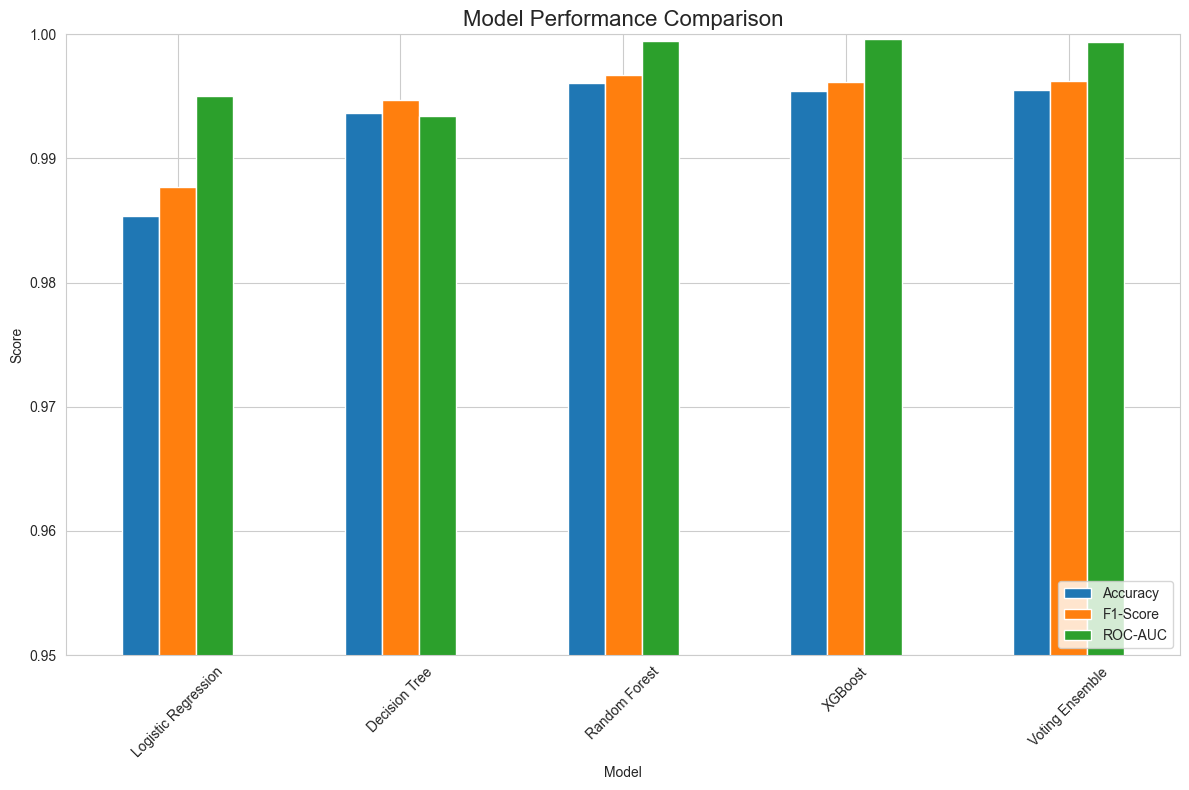

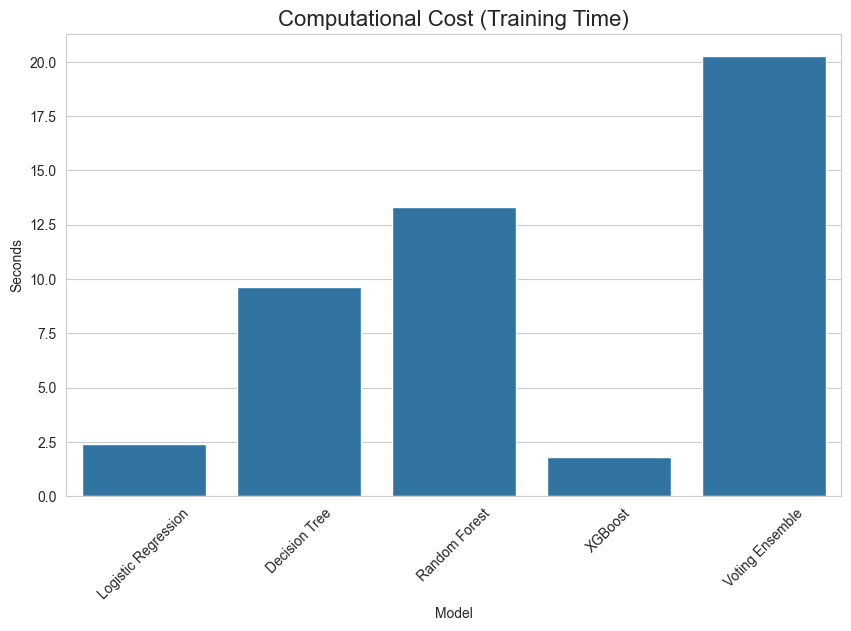

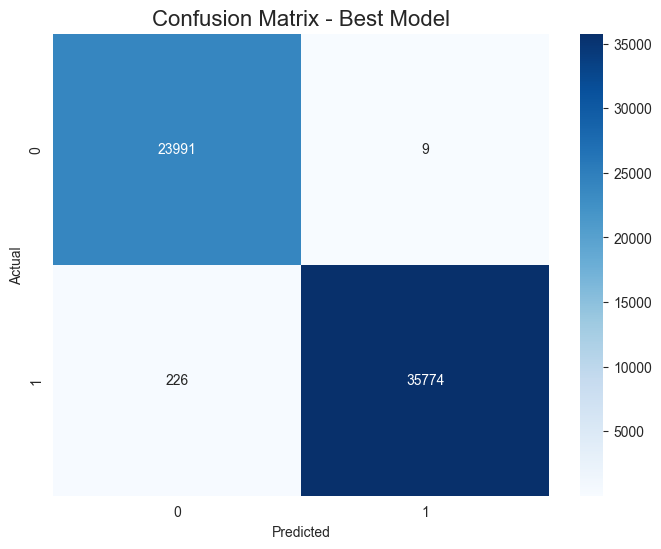


--- Running SHAP Analysis ---
Generating SHAP Summary Plot...


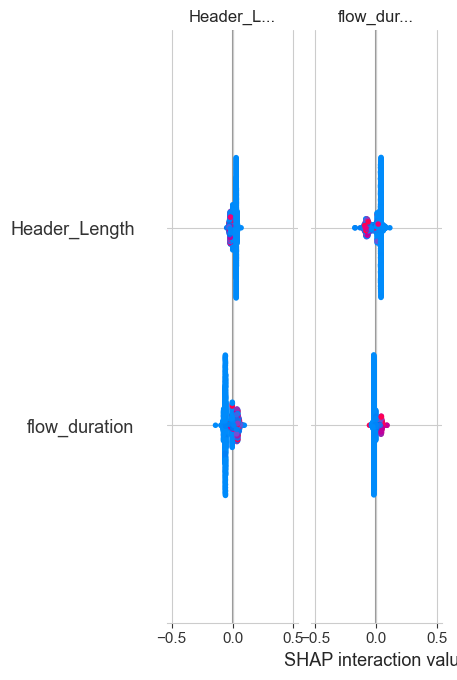

✅ Feature config saved!


In [18]:
# ---------------------------------------------------------
# STEP 5: EXECUTION & VISUALIZATION
# ---------------------------------------------------------

path_to_dataset = r"C:\Users\Anmol Srivastava\Desktop\8th sem project\CICIoT2023\*.csv"


try:
    # ------------------------------
    # LOAD DATA
    # ------------------------------
    X, y, feature_names = load_and_preprocess_data(
        path_to_dataset,
        total_samples=300000
    )
    
    # ------------------------------
    # TRAIN MODELS
    # ------------------------------
    results_df, best_model, X_test, y_test = train_and_evaluate(X, y)
    
    print("\n--- Final Results ---")
    print(results_df)

    # ------------------------------
    # 1. PERFORMANCE COMPARISON 
    # ------------------------------
    plt.figure(figsize=(12, 6))
    
    metrics = ['Accuracy', 'F1-Score', 'ROC-AUC']
    
    results_df.set_index('Model')[metrics].plot(kind='bar')
    
    plt.title('Model Performance Comparison', fontsize=16)
    plt.ylabel('Score')
    plt.xticks(rotation=45)
    plt.ylim(0.95, 1.00)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
    
    # ------------------------------
    # 2. TRAINING TIME
    # ------------------------------
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x='Model',
        y='Training Time (s)',
        data=results_df
    )
    
    plt.title('Computational Cost (Training Time)', fontsize=16)
    plt.ylabel('Seconds')
    plt.xticks(rotation=45)
    plt.show()
    
    # ------------------------------
    # 3. CONFUSION MATRIX (BEST MODEL)
    # ------------------------------
    y_pred_best = best_model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred_best)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix - Best Model', fontsize=16)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    # ------------------------------
    # 4. SHAP ANALYSIS (CORE UPGRADE)
    # ------------------------------
    print("\n--- Running SHAP Analysis ---")
    
    # Extract actual model if pipeline
    if hasattr(best_model, "named_steps"):
        model_for_shap = best_model.named_steps["model"]
    else:
        model_for_shap = best_model
    
    # Sample for speed
    sample_size = min(1000, len(X_test))
    X_sample = X_test.sample(n=sample_size, random_state=42)
    
    if hasattr(model_for_shap, "feature_importances_") or "XGB" in str(type(model_for_shap)):
        explainer = shap.TreeExplainer(model_for_shap)
    else:
        explainer = shap.Explainer(model_for_shap, X_sample)
    shap_values = explainer.shap_values(X_sample)
    
    # ------------------------------
    # SHAP SUMMARY PLOT
    # ------------------------------
    print("Generating SHAP Summary Plot...")
    
    shap.summary_plot(
        shap_values[1] if isinstance(shap_values, list) else shap_values,
        X_sample,
        show=True
    )
    
    # ------------------------------
    # SAVE GLOBAL IMPORTANCE (FIXED)
    # ------------------------------
    # If shap_values is a list (older SHAP), take the index for the 'Attack' class (usually 1)
    # If it's a 3D array (newer SHAP), extract the values for class 1: shap_values[:, :, 1]
    
    if isinstance(shap_values, list):
        vals = shap_values[1]
    elif len(shap_values.shape) == 3:
        vals = shap_values[:, :, 1]
    elif hasattr(shap_values, "values"): # If it's an Explanation object
        vals = shap_values.values
        if len(vals.shape) == 3:
            vals = vals[:, :, 1]
    else:
        vals = shap_values
        
    shap_importance = np.abs(vals).mean(axis=0)
    
    importance_df = pd.DataFrame({
        "Feature": X_sample.columns,
        "Importance": shap_importance
    }).sort_values(by="Importance", ascending=False)
    
    importance_df.to_csv("shap_global_importance.csv", index=False)

    # SAVE FEATURE CONFIG
    feature_config = {
        "features": feature_names,
        "count": len(feature_names)
    }

    with open("feature_config.json", "w") as f:
        json.dump(feature_config, f)

    print("✅ Feature config saved!")

except Exception as e:
    print(f"An error occurred: {e}")

In [19]:
import json

feature_config = {
    "features": feature_names,
    "count": len(feature_names)
}

with open("feature_config.json", "w") as f:
    json.dump(feature_config, f)

print("✅ Feature config saved!")

✅ Feature config saved!
